# Découpage administratif

`Bound` télécharge des frontières administratives depuis **GeoBoundaries**
(et Natural Earth pour les continents). On peut demander :

- un **continent** entier,
- un **pays** (niveau ADM0),
- un pays à un **niveau de découpage** donné (régions, départements, communes…),
- **plusieurs territoires** en un seul appel.

Un territoire s'indique par son nom, son code ISO2 ou son code ISO3 —
les trois sont équivalents.

In [1]:
import logging
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))  # cartograpy est à la racine du dépôt
logging.basicConfig(level=logging.INFO, format="%(message)s")

import cartograpy as cp
from cartograpy.data import Bound

bound = Bound()

C:\Users\Ordinateur\AppData\Roaming\uv\python\cpython-3.12-windows-x86_64-none\Lib\importlib\metadata\__init__.py:467: DeprecationWarning: Implicit None on return values is deprecated and will raise KeyErrors.
  return self.metadata['Version']


## Les niveaux administratifs

GeoBoundaries numérote les niveaux de `ADM0` (pays) à `ADM5`. Tous les pays
n'ont pas tous les niveaux.

In [2]:
print(bound.adminLevels())


| Niveau GeoBoundaries | Nom commun (FR)           | Nom commun (EN)       |
| -------------------- | ------------------------- | --------------------- |
| ADM0                 | Pays                      | Country               |
| ADM1                 | Région / État / Province  | State / Region        |
| ADM2                 | Département / District    | District / County     |
| ADM3                 | Sous-préfecture / Commune | Subdistrict / Commune |
| ADM4                 | Village / Localité        | Village / Locality    |
| ADM5                 | Quartier / Secteur        | Neighborhood / Sector |
        


## Un continent

`get_continent` accepte le nom en français ou en anglais.

📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


   Étendue: [-44.95, 78.46, -39.87, 42.40]


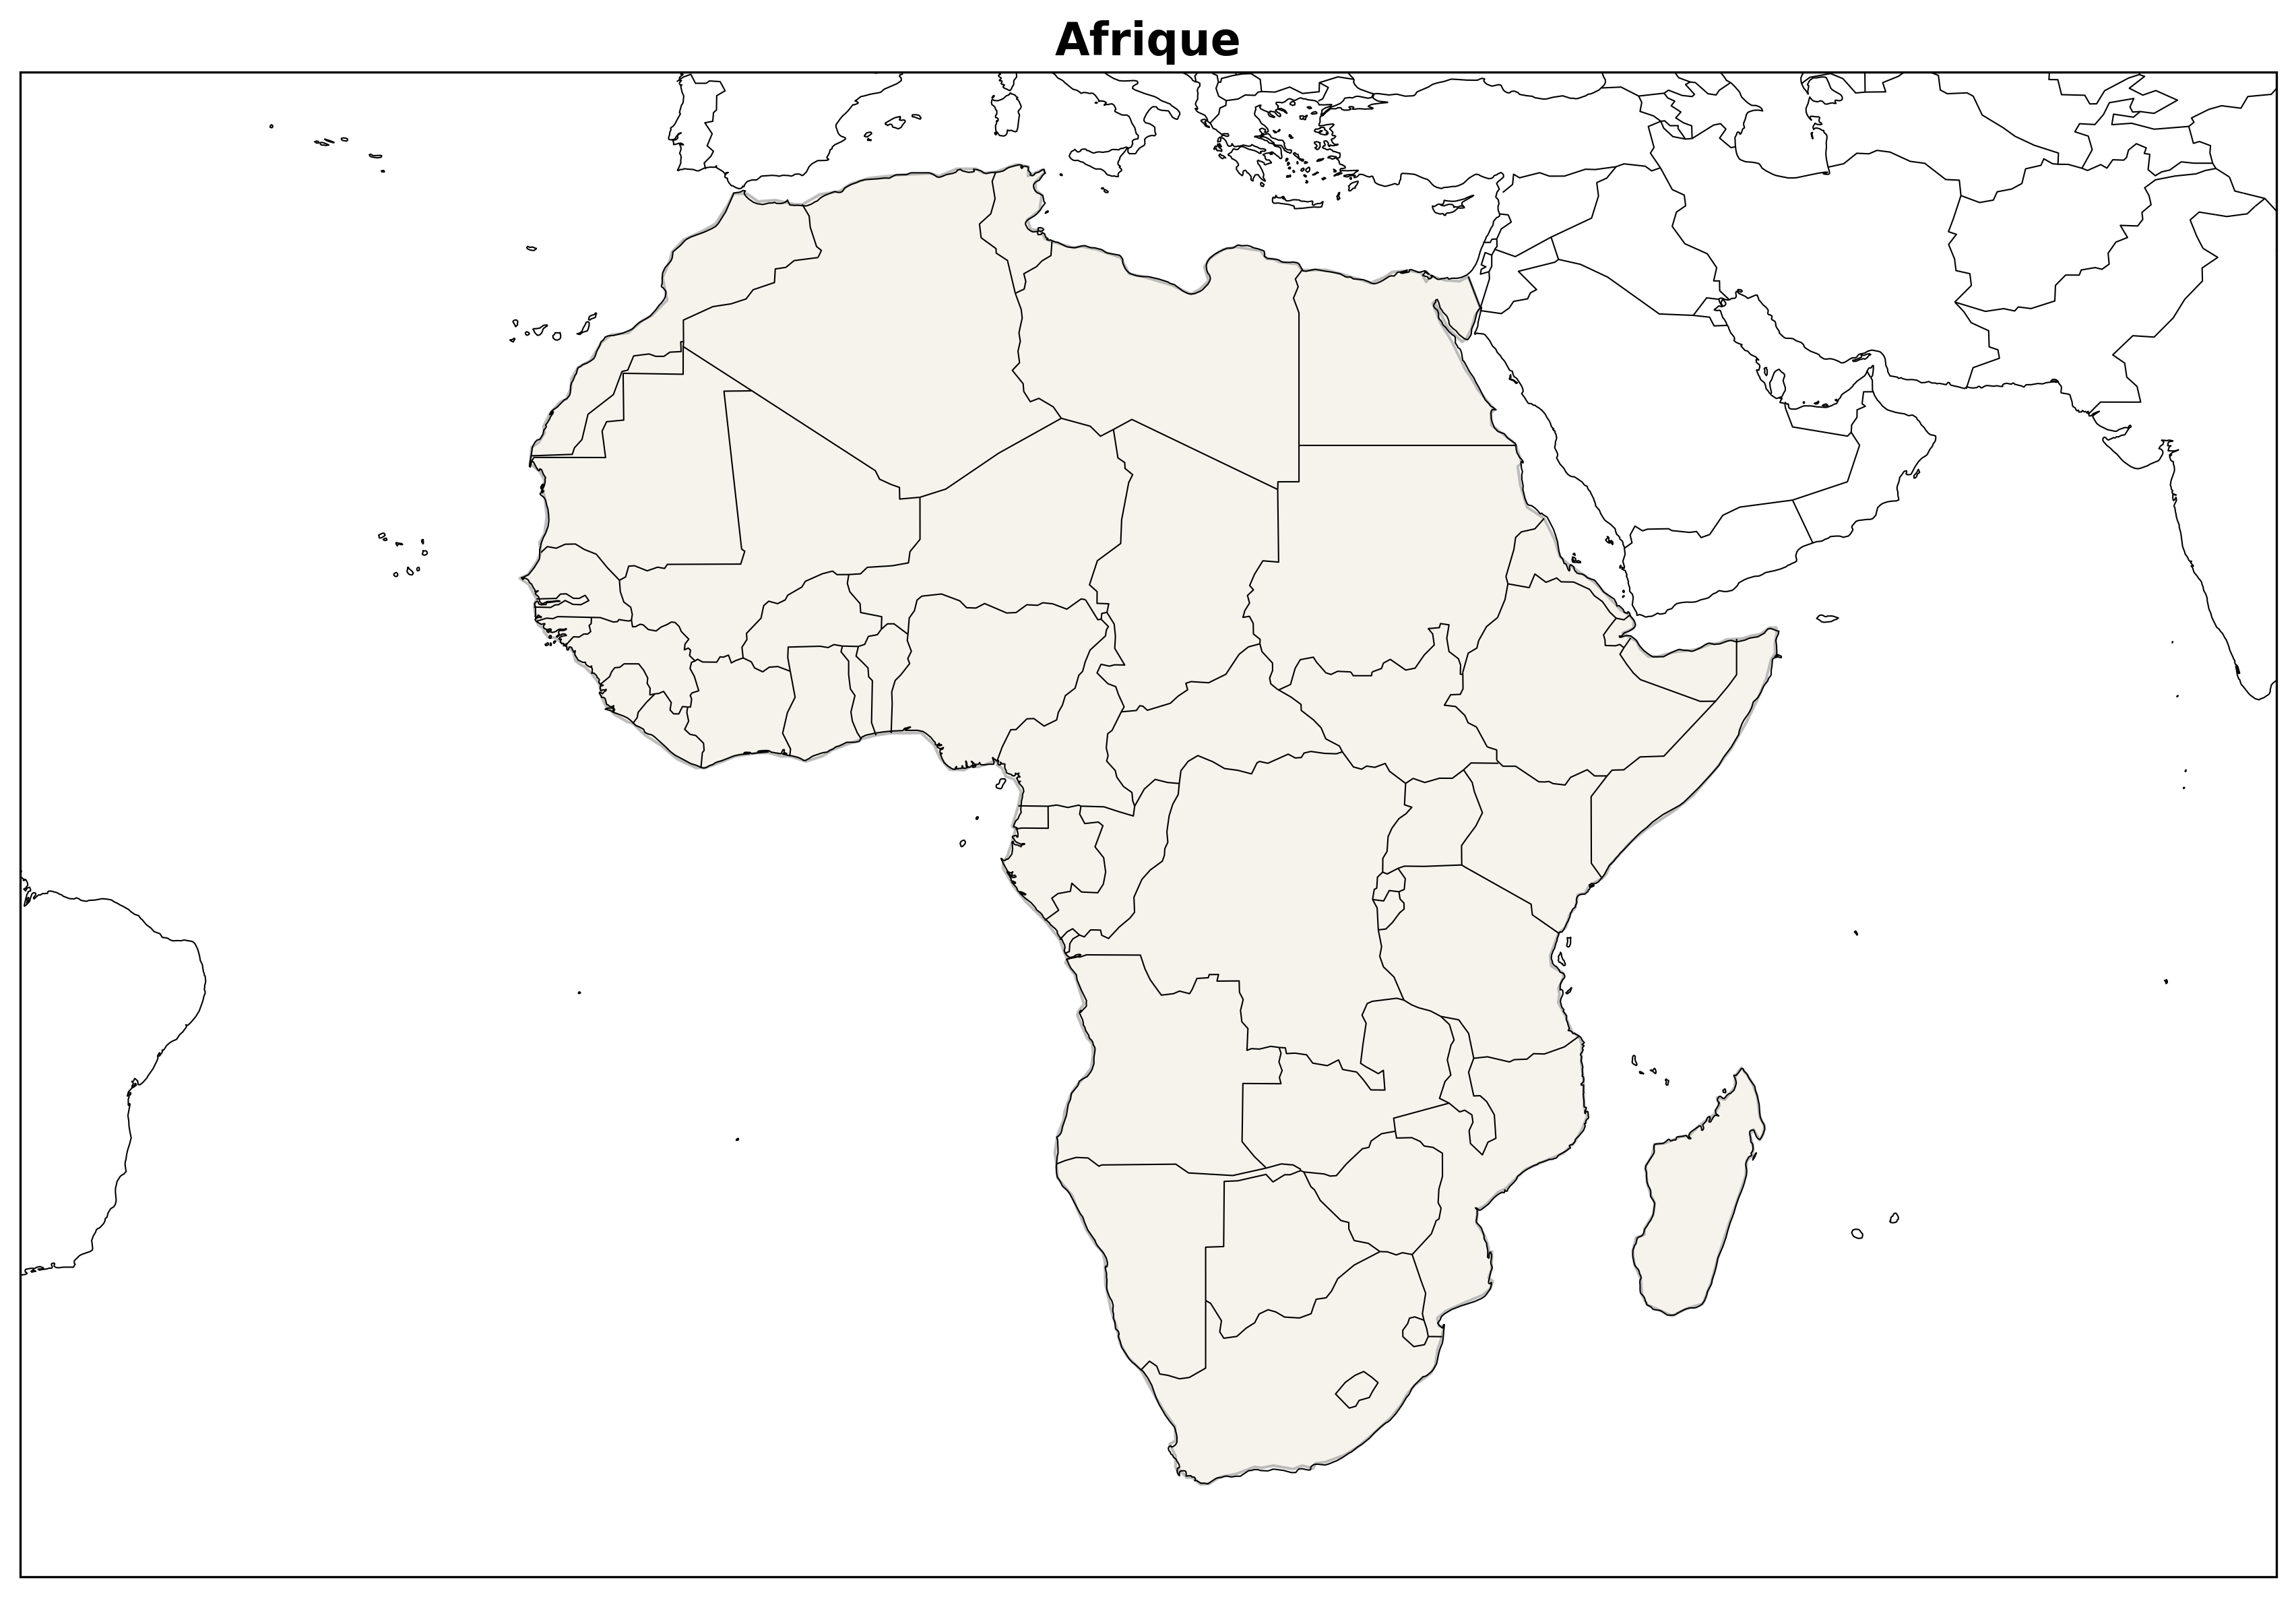

In [3]:
afrique = bound.get_continent("Afrique")

m = cp.Map(title="Afrique")
m.add_polygons(afrique, facecolor="#efe9dc", edge_color="grey")
m.show()

In [4]:
# Tous les continents en un GeoDataFrame
bound.get_world("continent")[["continent"]]

,continent
0,Africa
1,Antarctica
2,Asia
3,Europe
4,North America
5,Oceania
6,Seven seas (open ocean)
7,South America


## Un pays (ADM0)

`get_country` renvoie les frontières nationales. GeoBoundaries ne fixe pas
le système de coordonnées sur la réponse : les géométries sont en degrés
(WGS 84), on le déclare avec `set_crs("EPSG:4326")`.

In [5]:
civ = bound.get_country("Côte d'Ivoire").set_crs("EPSG:4326")
# équivalent : bound.get_country("CIV")  /  bound.get_country("CI")

civ[["shapeName", "shapeGroup", "geometry"]]

,shapeName,shapeGroup,geometry
0,Côte d’Ivoire,CIV,"MULTIPOLYGON (((-7.98966 10.16199, -7.99984 10..."


## Niveaux de découpage d'un pays

On passe `adm=` (0 à 5, ou l'étiquette `"ADM1"`). Ici les régions (ADM1)
et les départements (ADM2) de Côte d'Ivoire.

In [6]:
regions = bound.get_admin("CIV", adm=1).set_crs("EPSG:4326")
departements = bound.get_admin("CIV", adm=2).set_crs("EPSG:4326")

print(len(regions), "régions (ADM1)")
print(len(departements), "départements (ADM2)")

14 régions (ADM1)
33 départements (ADM2)


🧭 Flèche du Nord ajoutée (map-utils)


📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 0.95


   Étendue: [-11.00, -0.08, 3.91, 11.19]


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


C:\Users\Ordinateur\OneDrive\cartograpy\.venv\Lib\site-packages\matplotlib_map_utils\core\scale_bar.py:781: UserWarning: Provided CRS EPSG:4326 uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.
  warnings.warn(f"Provided CRS {bar_projection} uses degrees. An attempt will be made at conversion, but there will be accuracy issues: it is recommended that you use a projected CRS instead.")


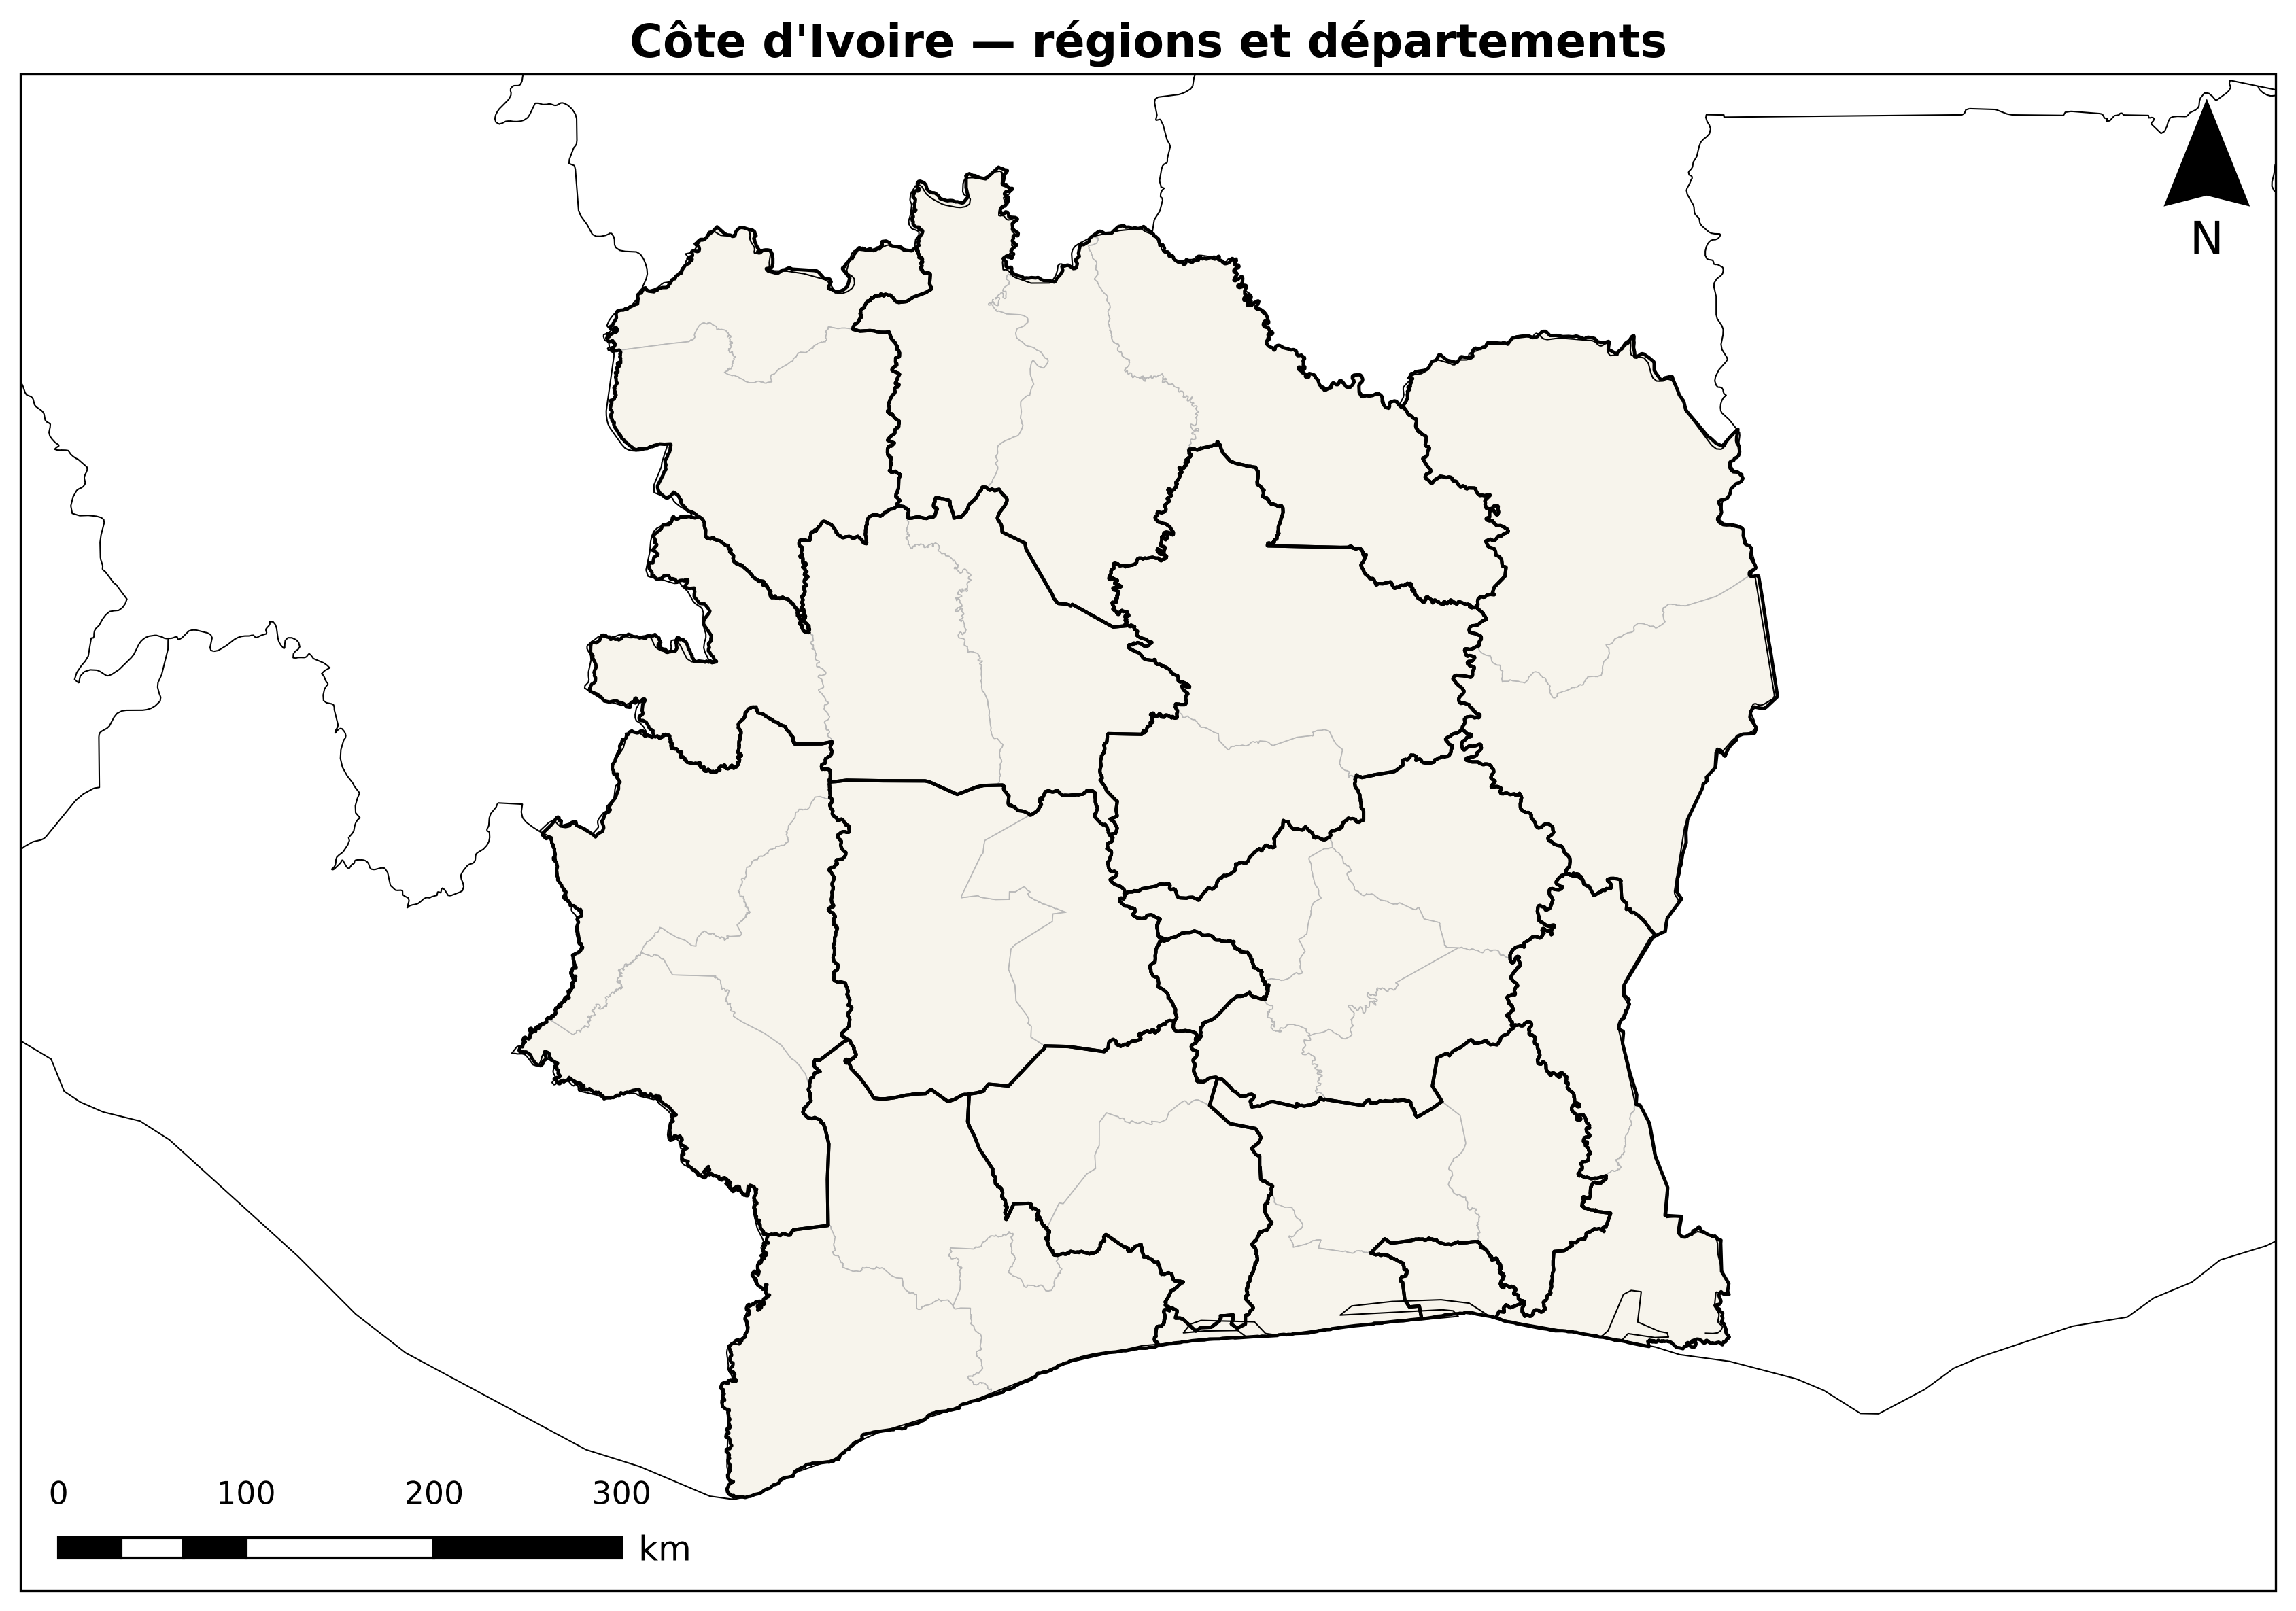

In [7]:
m = cp.Map(title="Côte d'Ivoire — régions et départements")
m.add_polygons(departements, facecolor="#f7f4ec", edge_color="#b8b8b8", linewidth=0.4, alpha=1)
m.add_polygons(regions, facecolor="none", edge_color="black", linewidth=1.2, alpha=1)
m.add_north_arrow()
m.add_scale_bar()
m.show()

### Le niveau le plus fin disponible

`adm=-1` demande automatiquement le plus petit niveau que GeoBoundaries
publie pour ce pays.

In [8]:
fin = bound.get_admin("CIV", adm=-1)
print("Niveau le plus fin :", len(fin), "entités")

Smallest ADM level found for CIV : ADM3


Niveau le plus fin : 510 entités


## Plusieurs territoires en un appel

`get_admin` accepte une liste ; les résultats sont concaténés.

📊 Centrage intelligent appliqué:


   Format: Personnalisé (N/A)


   Ratio figure: 1.50


   Ratio données: 2.37


   Étendue: [-20.44, 26.91, 0.44, 32.00]


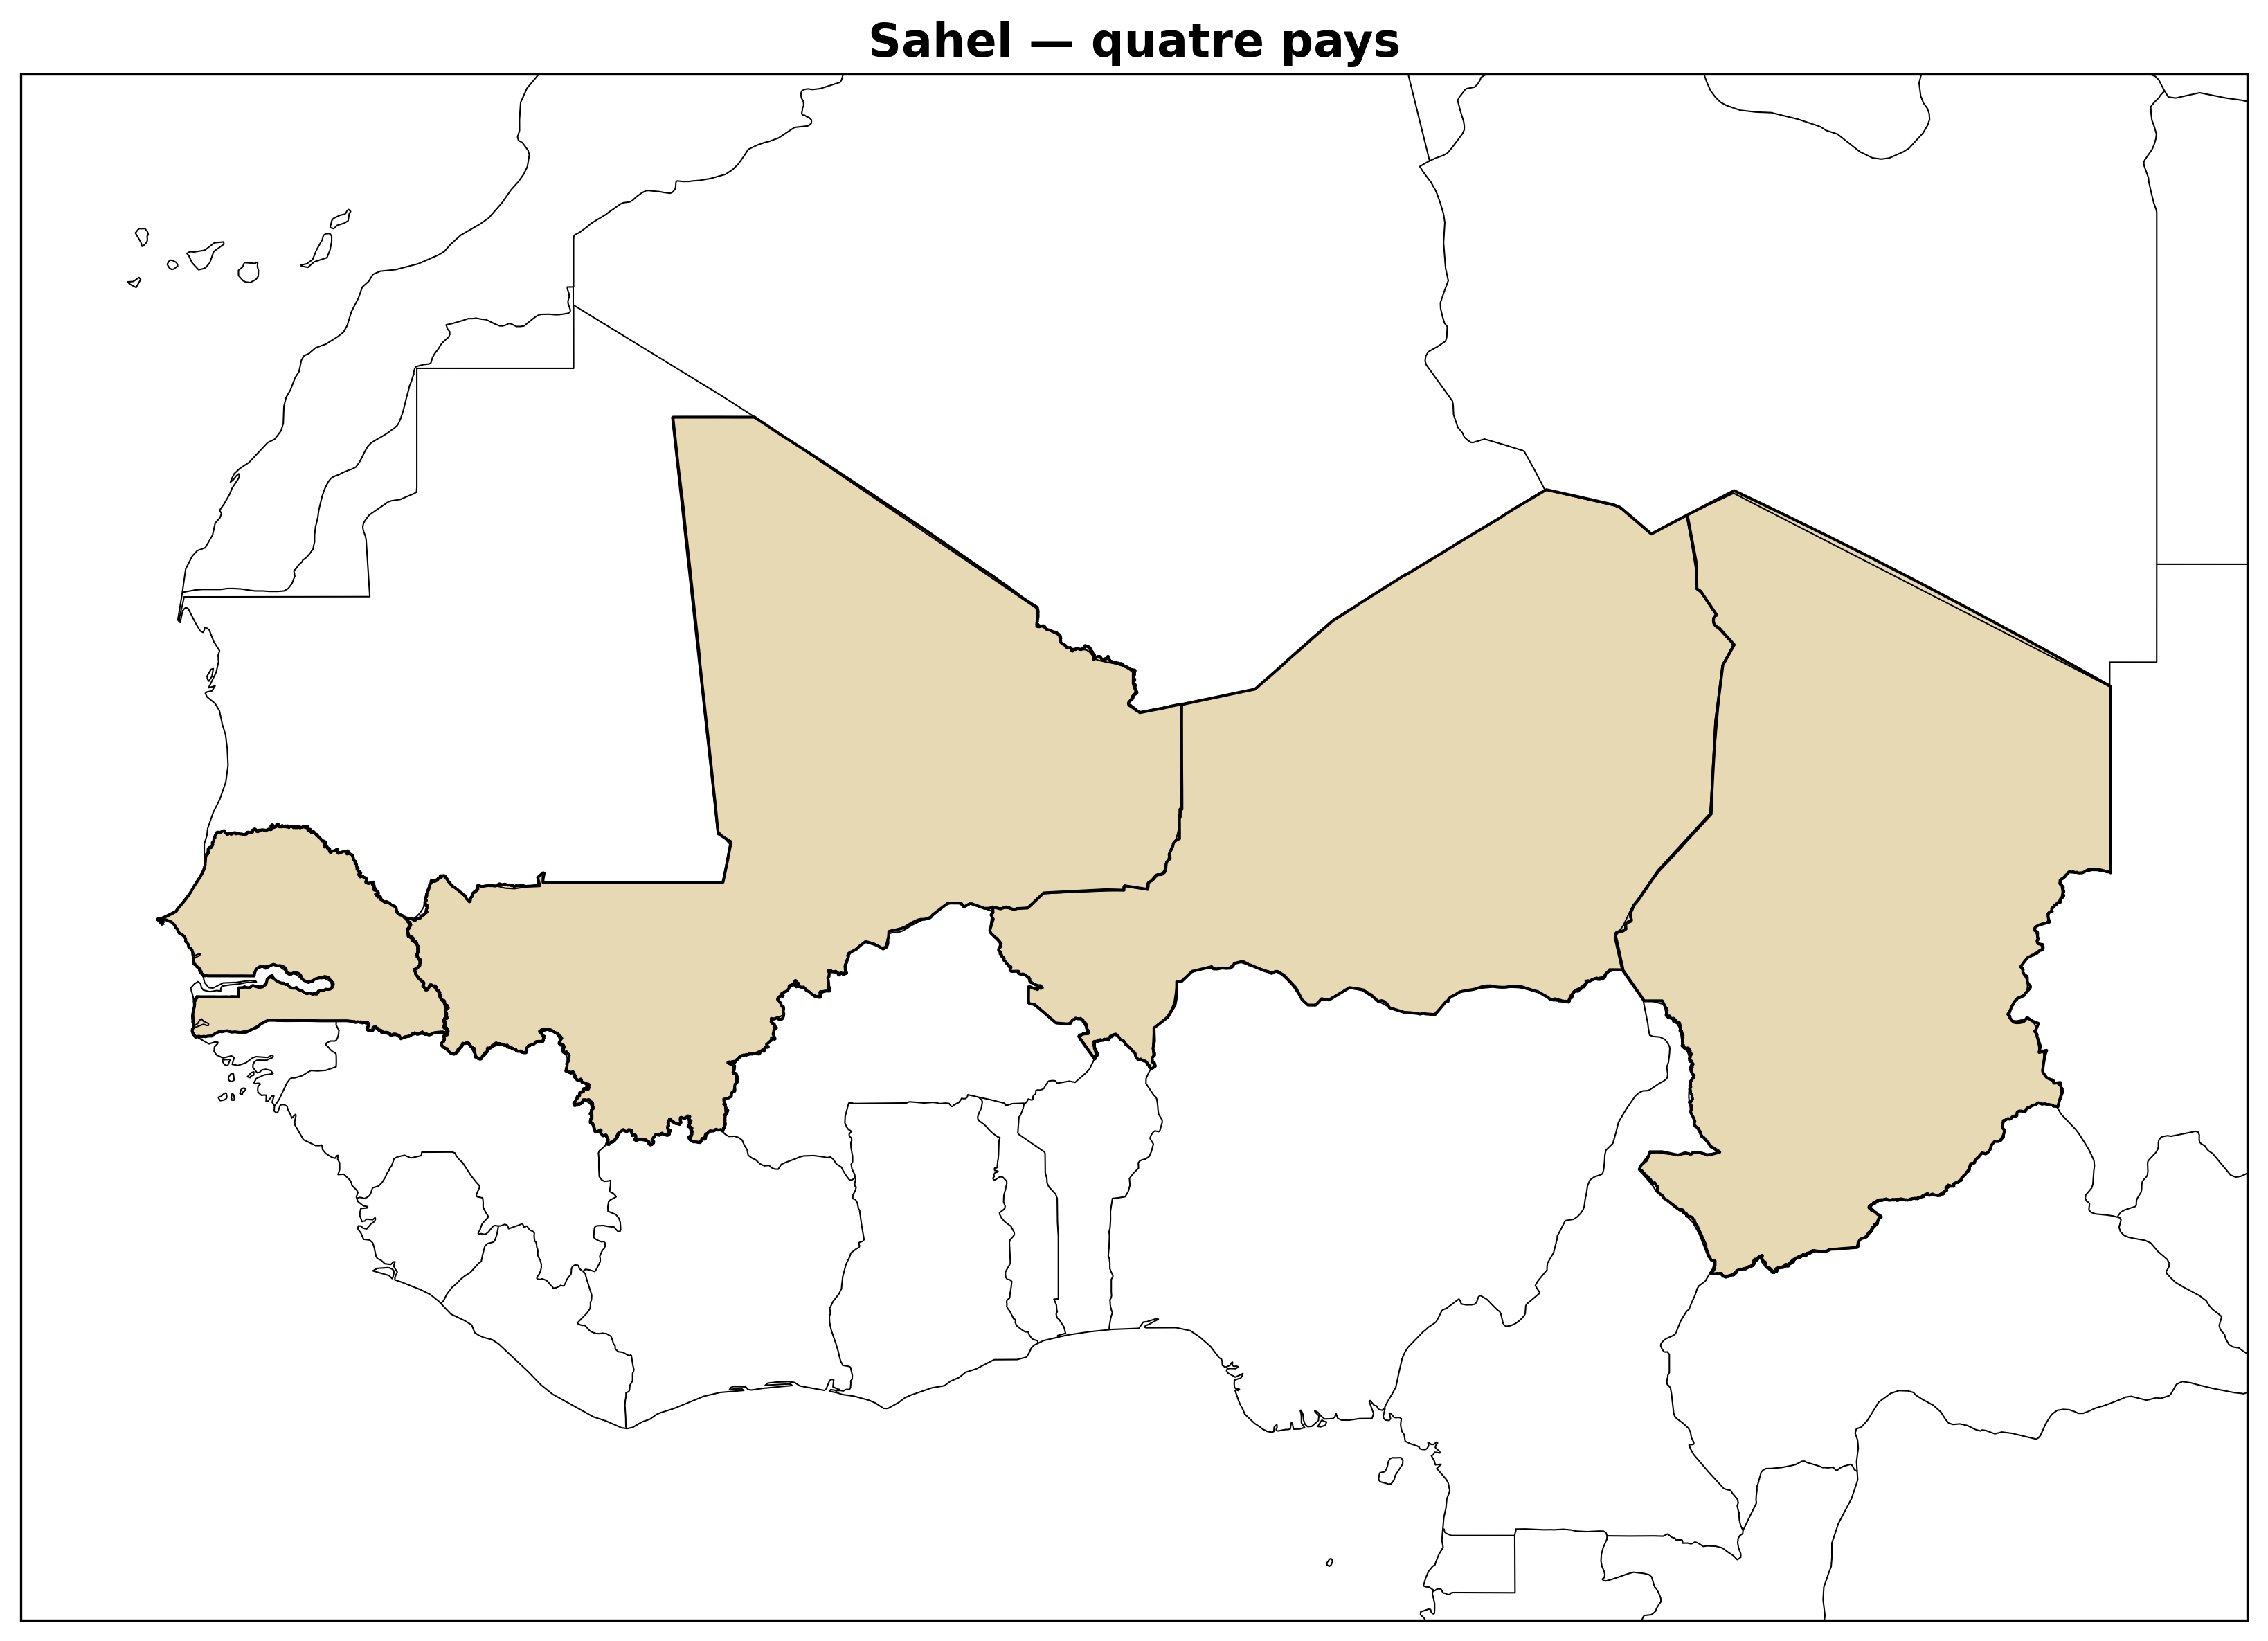

In [9]:
sahel = bound.get_admin(["SEN", "MLI", "NER", "TCD"], adm=0).set_crs("EPSG:4326")

m = cp.Map(title="Sahel — quatre pays")
m.add_polygons(sahel, facecolor="#e8d9b5", edge_color="black", alpha=1)
m.show()

## Retrouver un code, chercher un pays, lire les métadonnées

In [10]:
print("recherche floue :", bound.search_country("ivo"))
print("nom -> ISO3     :", bound.get_iso3("Ghana"))

meta = bound.metadata("CIV", "ADM1")
{k: meta[k] for k in ("boundaryName", "boundaryType", "boundaryYearRepresented", "boundarySource-1") if k in meta}

recherche floue : [("côte d'ivoire", 'civ'), ('ivoorkust', 'civ'), ('maldivoj', 'mdv')]
nom -> ISO3     : GHA


{'boundaryName': "Côte d'Ivoire",
 'boundaryType': 'ADM1',
 'boundaryYearRepresented': '2016'}